In [3]:
!pip install -q mne
from google.colab import drive
import zipfile
import os
import mne
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')



# 2. Define paths (Update 'zip_path' if your zip file is named differently in your Drive)
zip_path = '/content/dataverse_files.zip'
extract_path = '/content/dataset_unzipped'

# 3. Unzip the file
if not os.path.exists(extract_path):
    print("Extracting ZIP file...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("Dataset already extracted.")

# 4. Feature Extraction Function
def extract_eeg_features(data_dir):
    features, labels = [], []

    # Traverse to find the exact folder containing the .edf files (handles nested zip folders)
    target_dir = data_dir
    for root, dirs, files in os.walk(data_dir):
        if any(f.endswith('.edf') for f in files):
            target_dir = root
            break

    edf_files = [f for f in os.listdir(target_dir) if f.endswith('.edf')]
    print(f"Found {len(edf_files)} EDF files. Extracting tabular features...")

    for file in edf_files:
        file_path = os.path.join(target_dir, file)
        # Target assignment based on naming convention: h -> 0 (healthy), s -> 1 (schizophrenia)
        label = 0 if file.startswith('h') else 1

        try:
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            data = raw.get_data()
            ch_names = raw.ch_names

            row_features = {}
            for i, ch in enumerate(ch_names):
                row_features[f'{ch}_var'] = np.var(data[i])
                row_features[f'{ch}_mean'] = np.mean(data[i])

            features.append(row_features)
            labels.append(label)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    df = pd.DataFrame(features)
    df['target'] = labels
    return df

# 5. Execute Extraction
df = extract_eeg_features(extract_path)
print("Feature extraction complete! Dataset Shape:", df.shape)
display(df.head())

Extracting ZIP file...
Found 28 EDF files. Extracting tabular features...
Feature extraction complete! Dataset Shape: (28, 39)


,Fp2_var,Fp2_mean,F8_var,F8_mean,T4_var,T4_mean,T6_var,T6_mean,O2_var,O2_mean,...,C3_mean,P3_var,P3_mean,Fz_var,Fz_mean,Cz_var,Cz_mean,Pz_var,Pz_mean,target
0,1.439717e-10,2.097983e-09,9.064886e-11,-2.493169e-10,4.559681e-11,7.112611e-09,1.324572e-10,9.350811e-09,3.849797e-10,5.471484e-09,...,4.233696e-09,6.371640e-11,8.953423e-09,1.870741e-11,1.732334e-09,1.648798e-11,1.783908e-09,7.135413e-11,3.775477e-09,0
1,8.182327e-11,-1.588468e-09,4.754123e-11,-1.250934e-09,1.539777e-11,6.154496e-09,5.238427e-11,1.271419e-08,1.765001e-10,4.025245e-09,...,5.445908e-10,6.638896e-11,1.790672e-09,6.161312e-11,-4.131388e-09,5.245384e-11,-1.922829e-09,5.882213e-11,2.083159e-09,1
2,2.087732e-10,-1.407424e-08,7.335322e-11,-1.355898e-09,1.556975e-11,1.948869e-09,4.440555e-11,1.066077e-08,5.269612e-11,6.531991e-09,...,6.046485e-10,9.536997e-12,1.387657e-09,4.609450e-11,-9.002069e-10,2.013530e-11,-1.795458e-09,1.274362e-11,3.848926e-09,0
3,8.213108e-11,4.407719e-10,4.608381e-11,3.856974e-09,1.537350e-11,3.960284e-09,1.594121e-11,2.964578e-09,2.265080e-11,-2.247219e-10,...,3.818312e-09,1.596939e-11,5.656342e-09,1.799684e-11,-7.190888e-10,8.912708e-12,2.682535e-09,7.970146e-12,1.534717e-09,0
4,1.153623e-10,-4.065175e-09,5.908674e-11,2.155207e-09,6.123171e-12,2.279548e-09,1.210909e-11,4.203128e-09,1.567067e-11,1.924673e-09,...,2.822613e-09,1.782607e-11,1.528800e-09,3.107621e-11,-2.312311e-09,1.467729e-11,1.758420e-10,1.452713e-11,5.408222e-09,0


In [4]:
def equal_width_binning_target(target_series, bins=4):
    """Equal width binning for continuous outcome data (regression constraint)."""
    return pd.cut(target_series, bins=bins, labels=False)

def calculate_entropy(target_series):
    """A1: Calculates entropy associated with the dataset."""
    if pd.api.types.is_float_dtype(target_series) or target_series.nunique() > 10:
        target_series = equal_width_binning_target(target_series, bins=4)

    probabilities = target_series.value_counts(normalize=True)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-9))
    return entropy

def calculate_gini(target_series):
    """A2: Calculates the Gini index value for the dataset."""
    if pd.api.types.is_float_dtype(target_series) or target_series.nunique() > 10:
        target_series = equal_width_binning_target(target_series, bins=4)

    probabilities = target_series.value_counts(normalize=True)
    gini = 1.0 - np.sum(probabilities**2)
    return gini

target = df['target']
print(f"Dataset Entropy: {calculate_entropy(target):.4f}")
print(f"Dataset Gini Index: {calculate_gini(target):.4f}")

Dataset Entropy: 1.0000
Dataset Gini Index: 0.5000


In [8]:
def calculate_gini_gain(data, feature, target_name, method, bins):
    total_gini = calculate_gini(data[target_name])
    weighted_gini = 0
    feature_data = data[feature]

    if pd.api.types.is_numeric_dtype(feature_data) and feature_data.nunique() > bins:
        feature_data = bin_feature(feature_data, method=method, bins=bins)

    for value in feature_data.dropna().unique():
        subset = data[feature_data == value]
        weighted_gini += (len(subset) / len(data)) * calculate_gini(subset[target_name])

    return total_gini - weighted_gini

def calculate_entropy_gain(data, feature, target_name, method, bins):
    total_entropy = calculate_entropy(data[target_name])
    weighted_entropy = 0
    feature_data = data[feature]

    if pd.api.types.is_numeric_dtype(feature_data) and feature_data.nunique() > bins:
        feature_data = bin_feature(feature_data, method=method, bins=bins)

    for value in feature_data.dropna().unique():
        subset = data[feature_data == value]
        weighted_entropy += (len(subset) / len(data)) * calculate_entropy(subset[target_name])

    return total_entropy - weighted_entropy

def find_root_node(data, target_name, features, method, bins):
    best_feature = None
    best_gain = -1
    gain_function = calculate_entropy_gain # Default to entropy for now

    for feature in features:
        gain = gain_function(data, feature, target_name, method, bins)
        if gain > best_gain:
            best_gain = gain
            best_feature = feature
    return best_feature, best_gain

def bin_feature(series, method='equal_width', bins=4):
    if method == 'equal_width':
        return pd.cut(series, bins=bins, labels=False, include_lowest=True)
    elif method == 'equal_freq':
        return pd.qcut(series, q=bins, labels=False, duplicates='drop')
    return series

class CustomDecisionTree:
    def __init__(self, max_depth=3, method='equal_width', bins=4):
        self.max_depth = max_depth
        self.method = method
        self.bins = bins
        self.tree = None

    def fit(self, data, target_name, features, depth=0):
        target = data[target_name]

        # Stopping logic
        if len(target.unique()) == 1:
            return target.iloc[0]
        if len(features) == 0 or depth >= self.max_depth:
            return target.mode()[0]

        # Determine current split feature
        best_feature, _ = find_root_node(data, target_name, features, self.method, self.bins)
        tree_node = {best_feature: {}}

        feature_data = data[best_feature]
        if pd.api.types.is_numeric_dtype(feature_data) and feature_data.nunique() > self.bins:
            feature_data = bin_feature(feature_data, method=self.method, bins=self.bins)

        remaining_features = [f for f in features if f != best_feature]

        for val in feature_data.dropna().unique():
            subset_df = data[feature_data == val].copy()
            if subset_df.empty:
                tree_node[best_feature][val] = target.mode()[0]
            else:
                tree_node[best_feature][val] = self.fit(subset_df, target_name, remaining_features, depth + 1)

        self.tree = tree_node
        return tree_node

custom_dt = CustomDecisionTree(max_depth=3)
features_list = [col for col in df.columns if col != 'target']
my_tree = custom_dt.fit(df, 'target', features_list)

import pprint
print("A5: Custom Decision Tree Sub-branches:")
pprint.pprint(my_tree)

A5: Custom Decision Tree Sub-branches:
{'T4_mean': {np.int64(0): np.int64(0),
             np.int64(1): {'C4_mean': {np.int64(0): np.int64(1),
                                       np.int64(1): {'Cz_var': {np.int64(0): np.int64(0),
                                                                np.int64(1): np.int64(0),
                                                                np.int64(2): np.int64(1),
                                                                np.int64(3): np.int64(1)}},
                                       np.int64(2): np.int64(0),
                                       np.int64(3): np.int64(0)}},
             np.int64(2): np.int64(1),
             np.int64(3): np.int64(1)}}


In [9]:
class CustomDecisionTree:
    def __init__(self, max_depth=3, method='equal_width', bins=4):
        self.max_depth = max_depth
        self.method = method
        self.bins = bins
        self.tree = None

    def fit(self, data, target_name, features, depth=0):
        target = data[target_name]

        # Stopping logic
        if len(target.unique()) == 1:
            return target.iloc[0]
        if len(features) == 0 or depth >= self.max_depth:
            return target.mode()[0]

        # Determine current split feature
        best_feature, _ = find_root_node(data, target_name, features, self.method, self.bins)
        tree_node = {best_feature: {}}

        feature_data = data[best_feature]
        if pd.api.types.is_numeric_dtype(feature_data) and feature_data.nunique() > self.bins:
            feature_data = bin_feature(feature_data, method=self.method, bins=self.bins)

        remaining_features = [f for f in features if f != best_feature]

        for val in feature_data.dropna().unique():
            subset_df = data[feature_data == val].copy()
            if subset_df.empty:
                tree_node[best_feature][val] = target.mode()[0]
            else:
                tree_node[best_feature][val] = self.fit(subset_df, target_name, remaining_features, depth + 1)

        self.tree = tree_node
        return tree_node

custom_dt = CustomDecisionTree(max_depth=3)
my_tree = custom_dt.fit(df, 'target', features_list)

import pprint
print("A5: Custom Decision Tree Sub-branches:")
pprint.pprint(my_tree)

A5: Custom Decision Tree Sub-branches:
{'T4_mean': {np.int64(0): np.int64(0),
             np.int64(1): {'C4_mean': {np.int64(0): np.int64(1),
                                       np.int64(1): {'Cz_var': {np.int64(0): np.int64(0),
                                                                np.int64(1): np.int64(0),
                                                                np.int64(2): np.int64(1),
                                                                np.int64(3): np.int64(1)}},
                                       np.int64(2): np.int64(0),
                                       np.int64(3): np.int64(0)}},
             np.int64(2): np.int64(1),
             np.int64(3): np.int64(1)}}


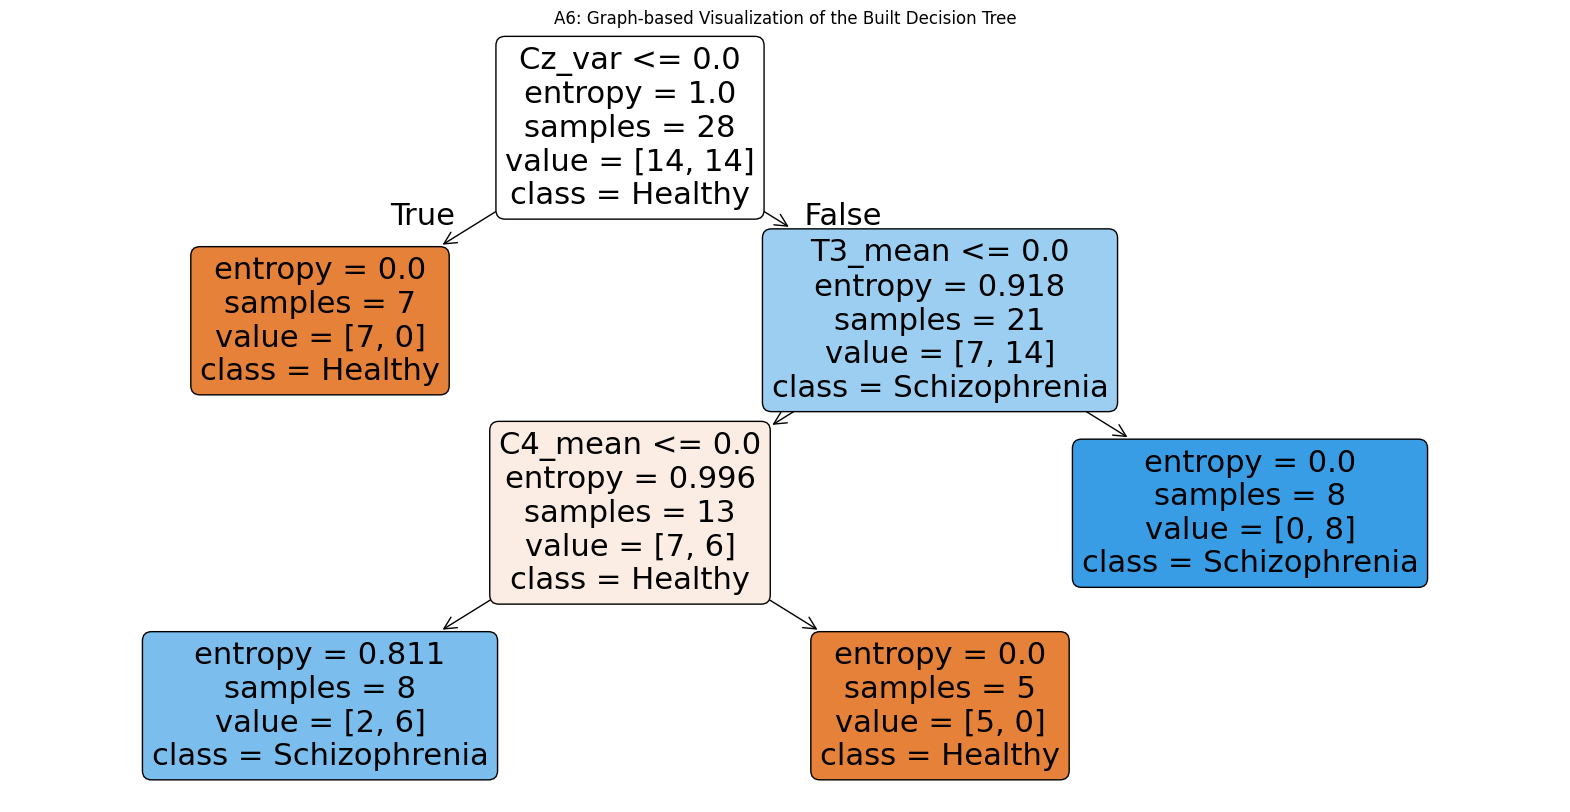

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = df.drop(columns=['target'])
y = df['target']

# Utilizing standard sklearn DT for precise tree plotting capabilities
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X, y)

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['Healthy', 'Schizophrenia'], filled=True, rounded=True)
plt.title("A6: Graph-based Visualization of the Built Decision Tree")
plt.show()

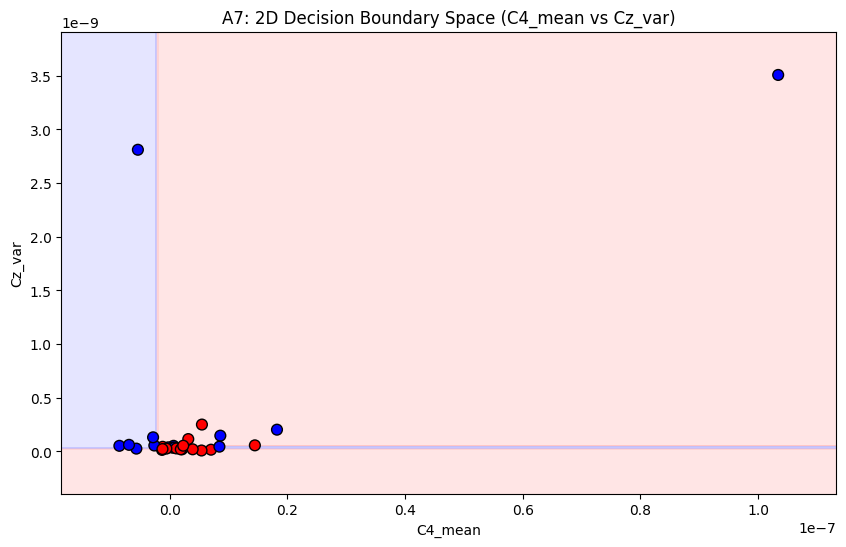

In [11]:
from matplotlib.colors import ListedColormap

# Select the top 2 features determined by standard feature importances
importances = clf.feature_importances_
top_2_indices = np.argsort(importances)[-2:]
feat1, feat2 = X.columns[top_2_indices[0]], X.columns[top_2_indices[1]]

X_2d = X[[feat1, feat2]].values
y_2d = y.values

clf_2d = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_2d.fit(X_2d, y_2d)

x_min, x_max = X_2d[:, 0].min() - (X_2d[:, 0].std() * 0.5), X_2d[:, 0].max() + (X_2d[:, 0].std() * 0.5)
y_min, y_max = X_2d[:, 1].min() - (X_2d[:, 1].std() * 0.5), X_2d[:, 1].max() + (X_2d[:, 1].std() * 0.5)

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=cmap_bold, edgecolor='k', s=60)
plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title(f"A7: 2D Decision Boundary Space ({feat1} vs {feat2})")
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV

# Note: CV is kept low (cv=3) to accommodate the smaller raw instance count (28 items)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 5, 10, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X, y)

print("\n--- A8: Hyper-parameter Tuning Results ---")
print("Ideal Hyper-parameters:", grid_search.best_params_)
print(f"Optimal Classifier Tuning Accuracy: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 90 candidates, totalling 270 fits

--- A8: Hyper-parameter Tuning Results ---
Ideal Hyper-parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Optimal Classifier Tuning Accuracy: 0.6333
